In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="http://127.0.0.1:5001/gateway/mlflow/v1",
    api_key="not-needed",
    model="workshop-gemini",
)

In [3]:
from typing import Annotated, Literal, TypedDict
from operator import add
from pydantic import BaseModel
from langgraph.graph import END, START, StateGraph
import sys
sys.path.append("../..")
from graph_image import show_graph

problem_statement = "Choose items within the capacity and maximize value. Each item may be selected at most once."

buggy_code = """
n, capacity = map(int, input().split())
items = [tuple(map(int, input().split())) for _ in range(n)]
dp = [0] * (capacity + 1)
for weight, value in items:
    for current in range(weight, capacity + 1):
        dp[current] = max(dp[current], dp[current - weight] + value)
print(dp[capacity])
"""

In [4]:
from asyncio import base_events
DEBUG_PROMPT = """
Debug the Python code. Review the previous steps before answering.
Give the best diagnosis and the smallest fix.
Set continue_loop to true only if another bug may remain.
Do not repeat a bug already found in the previous steps.
"""

class DebugStep(BaseModel):
    diagnosis: str
    fix: str
    continue_loop: bool

class TestCase(BaseModel): 
    # what i expect the ai generated test case to contain 
    input_data: str
    expected_output: str 
    explanation: str

step_llm = llm.with_structured_output(DebugStep)
test_llm= llm.with_structured_output(TestCase)
#  i want the llm to return this answer according to the test case schema 

# both these two lines with comments do no generate a test case 
# they just make sure what a test case should look like 

In [5]:
TEST_PROMPT = """
You are a test case generation agent.

Given the original code and the identified bug, generate ONE
small test case that exposes the bug.

The test case must:
1. Be valid input for the program.
2. Produce an incorrect result when run on the buggy code.
3. Include the correct expected output.
4. Explain why this test exposes the bug.

Keep the test case as small as possible.
"""

In [6]:
# this is the state 
class DebuggerState(TypedDict):
    problem: str
    code: str
    diagnosis: str
    test_case: dict


def generate_test(state):
    print("--> Running generate_test...")
    result = test_llm.invoke([ # actual call to the llm 
        {
            "role": "system",
            "content": TEST_PROMPT # system msg is the prompt here 
        },
        {
            "role": "user",
            "content": f"""
Problem:
{state['problem']}

Code:
{state['code']}

Diagnosis:
{state['diagnosis']}
"""
        }
    ])
    print("✓ Finished generate_test")

    return {
        "test_case": result.model_dump()
    }

    # f string allows us to insert variables 
    # here result is a pydantic obj but 
    # but the dictionary is easier to work with 
    # so we use return result  model.dump which  puts the dictionary into the test _ case and updates the langgraph 



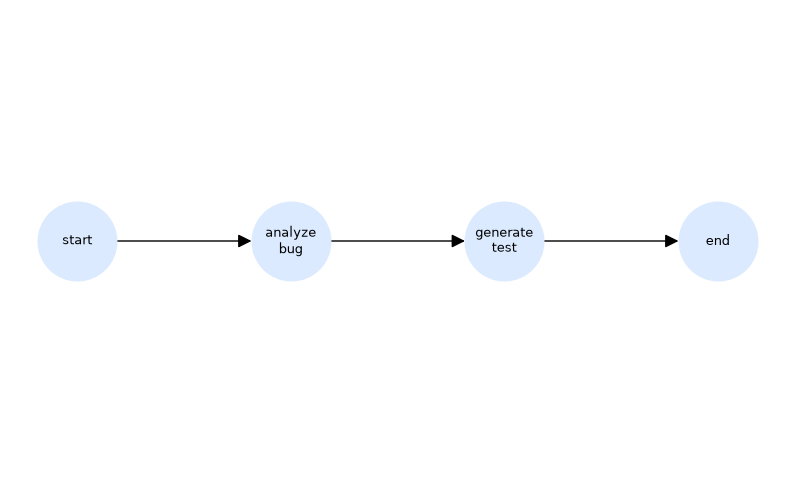

In [7]:
builder = StateGraph(DebuggerState)


def analyze_bug(state):
    print("--> Running analyze_bug...")
    result = step_llm.invoke([
        {
            "role": "system",
            "content": DEBUG_PROMPT
        },
        {
            "role": "user",
            "content": f"""
Problem:
{state['problem']}

Code:
{state['code']}
"""
        }
    ])

    print("✓ Finished analyze_bug")
    
    return {
        "diagnosis": result.diagnosis
    }


builder.add_node("analyze_bug", analyze_bug)
builder.add_node("generate_test", generate_test)
builder.add_edge(START, "analyze_bug")
builder.add_edge("analyze_bug", "generate_test")
builder.add_edge("generate_test", END)

graph = builder.compile()
show_graph(graph)

In [ ]:
result = graph.invoke({
    "problem": problem_statement,
    "code": buggy_code,
    "diagnosis": "",
    "test_case": {}
})

--> Running analyze_bug...
✓ Finished analyze_bug
--> Running generate_test...
✓ Finished generate_test


In [9]:
print(result)

{'problem': 'Choose items within the capacity and maximize value. Each item may be selected at most once.', 'code': '\nn, capacity = map(int, input().split())\nitems = [tuple(map(int, input().split())) for _ in range(n)]\ndp = [0] * (capacity + 1)\nfor weight, value in items:\n    for current in range(weight, capacity + 1):\n        dp[current] = max(dp[current], dp[current - weight] + value)\nprint(dp[capacity])\n', 'diagnosis': 'The inner loop iterates forward from weight to capacity + 1, which allows an item to be reused multiple times (unbounded knapsack). To solve the 0/1 knapsack problem where each item can be selected at most once, the inner loop must iterate backwards from capacity down to weight.', 'test_case': {'input_data': '1 2\n1 5', 'expected_output': '5', 'explanation': 'There is only one item available (weight 1, value 5) and the capacity is 2. Since each item can be selected at most once, the maximum value is 5. The buggy code iterates forward in the inner loop, reusin